In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# loading data

In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


CUDA available: True
Device count: 1
Device name: Tesla P100-PCIE-16GB


In [3]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image as IPyImage

from PIL import Image

# Exploring some Samples

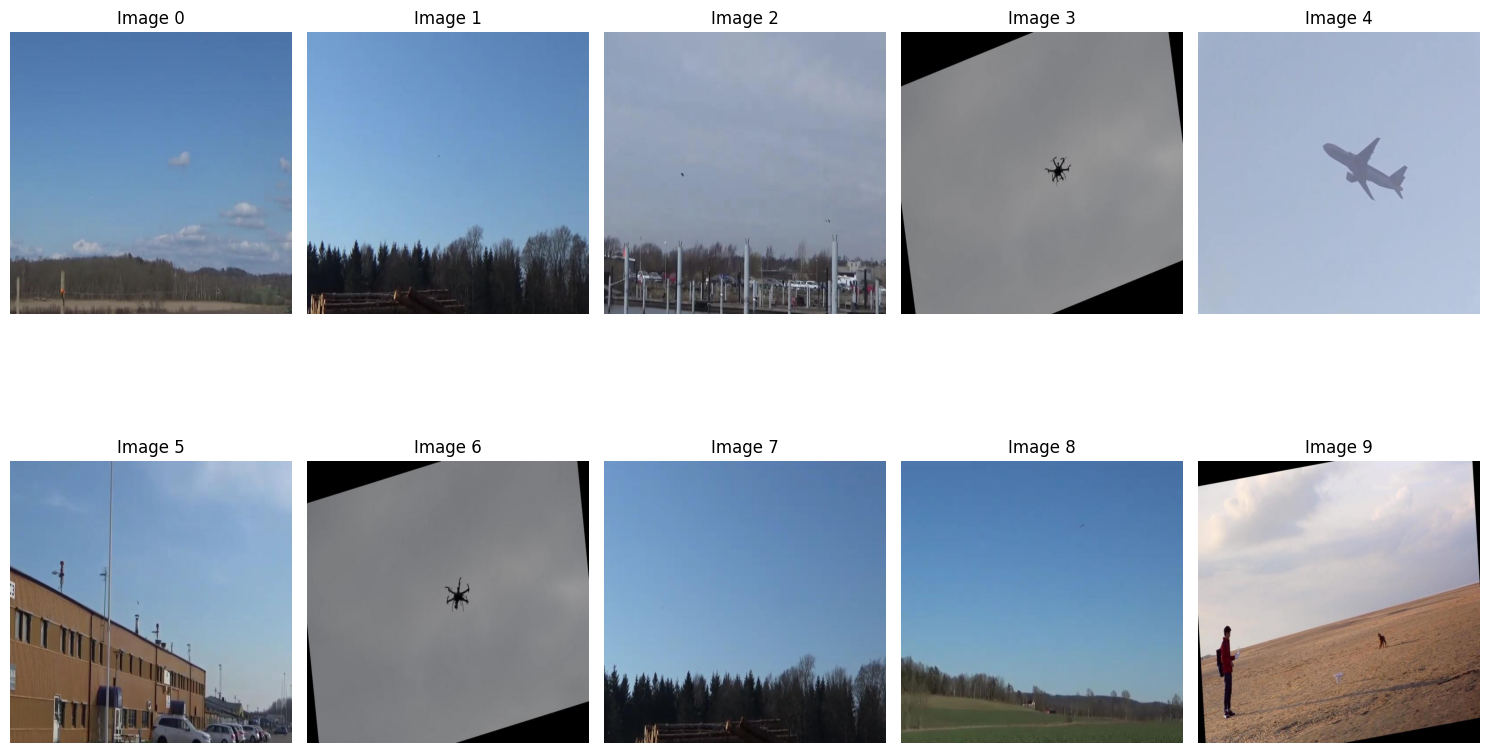

In [4]:

base_dir = '/kaggle/input/drone-detection-dataset/updated dataset'

image_files = [os.path.join(base_dir, 'train', 'images',x) for x in os.listdir(os.path.join(base_dir, 'train', 'images'))[:10]]
rows, cols = 2, 5
fig, axs = plt.subplots(rows, cols, figsize=(15, 10))

for i, ax in enumerate(axs.flat):
    if i<len(image_files):
        img = mpimg.imread(image_files[i])
        ax.imshow(img)
        ax.set_title(f"Image {i}")
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()    

In [7]:
! pip install ultralytics
from ultralytics import YOLO

# Training Model_1 (Yolo 11)

In [ ]:
# model = YOLO('yolo11s.pt') 
# yaml_dir = os.path.join(base_dir, 'data.yaml')

# results=model.train(
#     data=yaml_dir,
#     epochs=10,
#     batch=32,
#     imgsz=640,
#     patience=5,              # Early stopping
#     val=True,
#     name="run_1",
#     project="/kaggle/working/Dorne_detection_res",
#     device='cuda',
#     verbose=True,
#     exist_ok=True,
#     save=True
# )

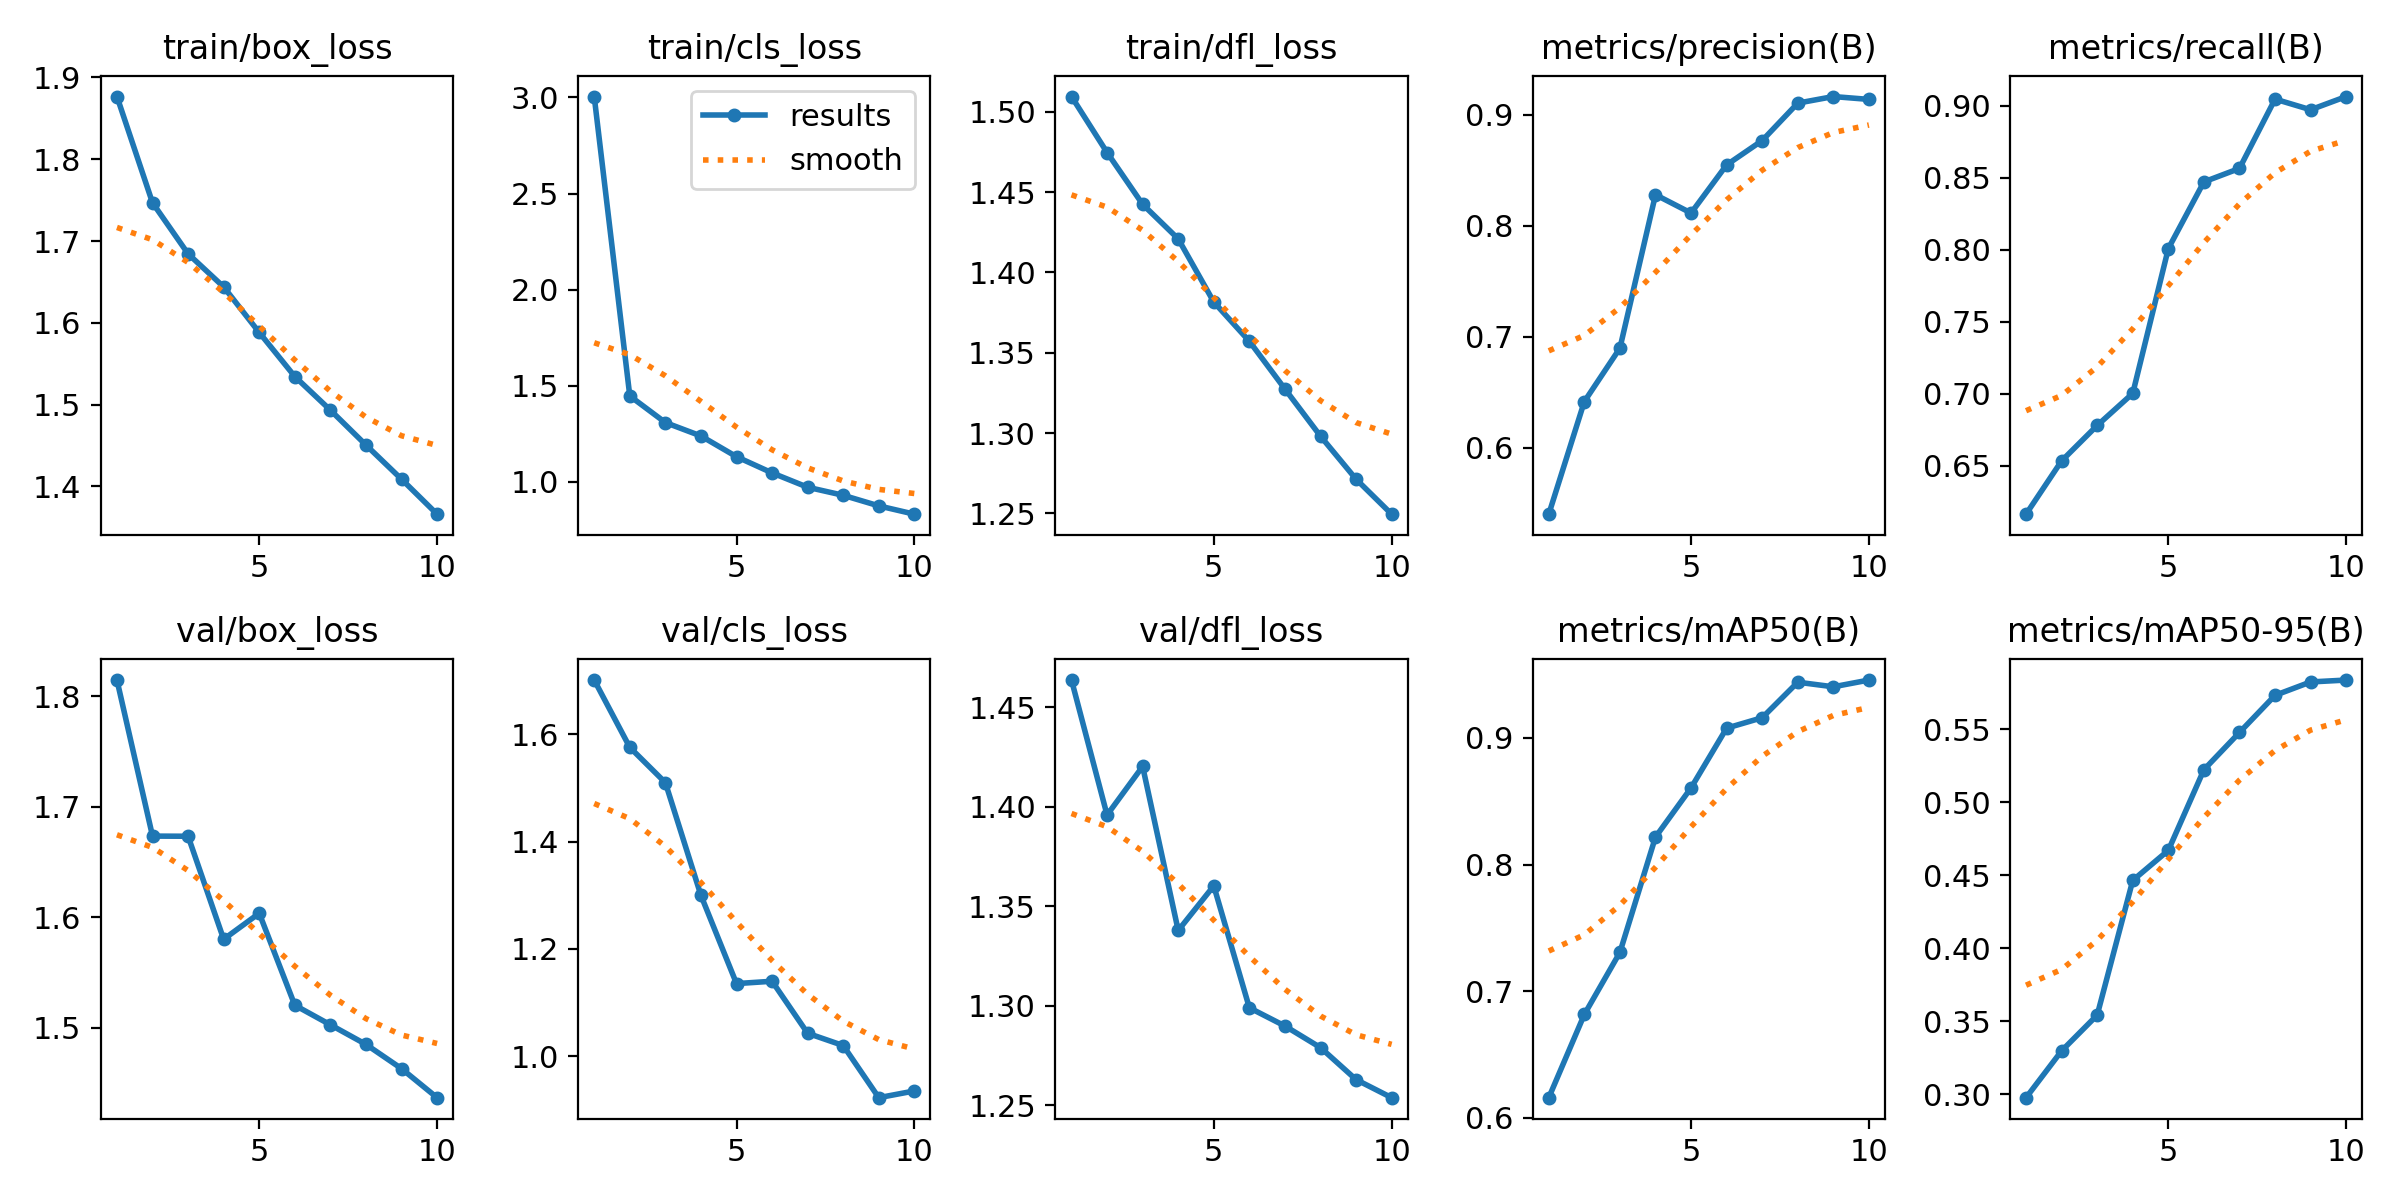

In [5]:
IPyImage('/kaggle/input/pretrained-model-2/results.png', width=600)


In [ ]:
# res=model.predict(
#     source='/kaggle/input/test-data2/Screenshot 2025-09-16 201214.png',  # Replace with your test image path
#     conf=0.36,        # Confidence threshold
#     iou=0.45,        # IoU threshold
#     save=True        # Saves annotated image to /kaggle/runs/detect/
# )


In [17]:
best_model_path = '/kaggle/input/pretrained-model-2/best.pt' # Path to the best weights from training
best_model = YOLO(best_model_path)

best_model.conf = 0.5     
best_model.iou = 0.45

In [ ]:
results = best_model.predict('/kaggle/input/drone-detection-dataset/updated dataset/valid/images', save=True, conf=0.5, iou=0.5)


In [57]:
metrics = model.val(data='/kaggle/input/drone-detection-dataset/updated dataset/data.yaml')  # Use your dataset config

Ultralytics 8.3.201 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.4 ms, read: 69.8±63.6 MB/s, size: 36.8 KB)
val: Scanning /kaggle/input/drone-detection-dataset/updated dataset/valid/labels... 765 images, 110 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 765/765 808.2it/s 0.9s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/drone-detection-dataset/updated dataset/valid is not writeable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 3.4it/s 7.1s0.2s


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        765        741      0.928      0.896      0.949       0.62
              AirPlane        133        133      0.923      0.897      0.974      0.695
                 Drone        382        468      0.927      0.842      0.898      0.452
            Helicopter        140        140      0.935       0.95      0.976      0.713
Speed: 1.0ms preprocess, 2.5ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /kaggle/working/model_2_res/run_1


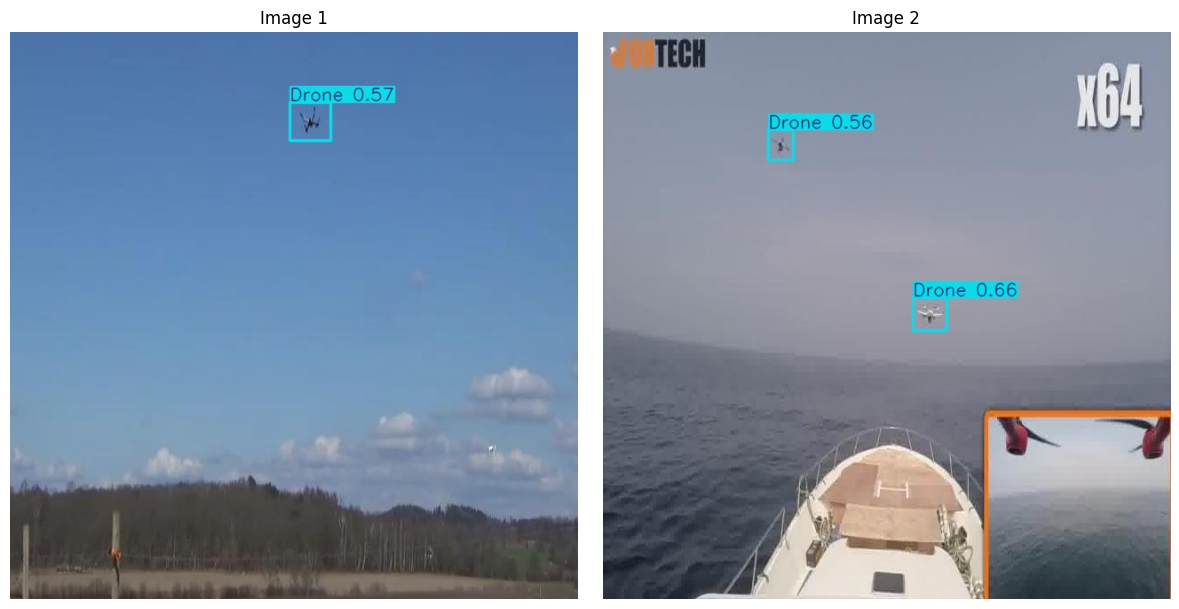

In [43]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load the images
img1 = mpimg.imread('/kaggle/working/runs/detect/predict/V_DRONE_106216_265_png.rf.3f6c83cfed825eaaeda1c1193e673d05.jpg')
img2 = mpimg.imread('/kaggle/working/runs/detect/predict/video18_1985_JPEG_jpg.rf.b40884bdbea85ecfbaf99d99a7ab2b38.jpg')

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Display each image
axs[0].imshow(img1)
axs[0].axis('off')
axs[0].set_title('Image 1')

axs[1].imshow(img2)
axs[1].axis('off')
axs[1].set_title('Image 2')


plt.tight_layout()
plt.show()


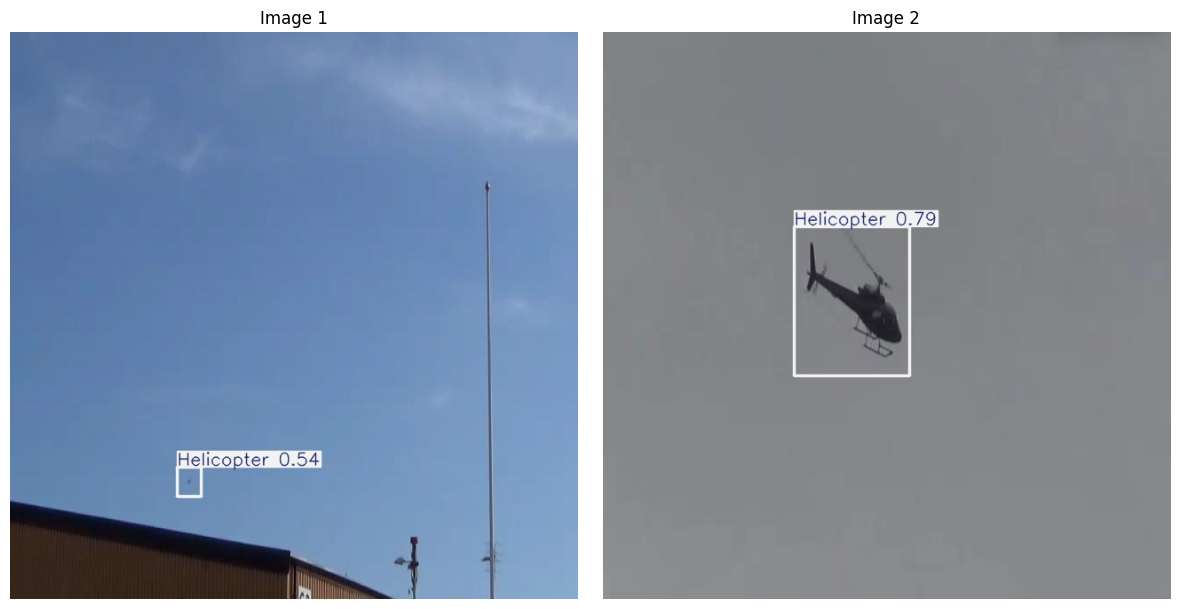

In [34]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load the images
img1 = mpimg.imread('/kaggle/working/runs/detect/predict/V_HELICOPTER_015239_306_png.rf.e50f9bf932a01af45919508e607c0236.jpg')
img2 = mpimg.imread('/kaggle/working/runs/detect/predict/V_HELICOPTER_023247_033_png.rf.b84027ce7cada34fbc5cc360ab81d8da.jpg')

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Display each image
axs[0].imshow(img1)
axs[0].axis('off')
axs[0].set_title('Image 1')

axs[1].imshow(img2)
axs[1].axis('off')
axs[1].set_title('Image 2')

axs[1].imshow(img2)
axs[1].axis('off')
axs[1].set_title('Image 2')

plt.tight_layout()
plt.show()


# Samples out of the distribution of the dataset

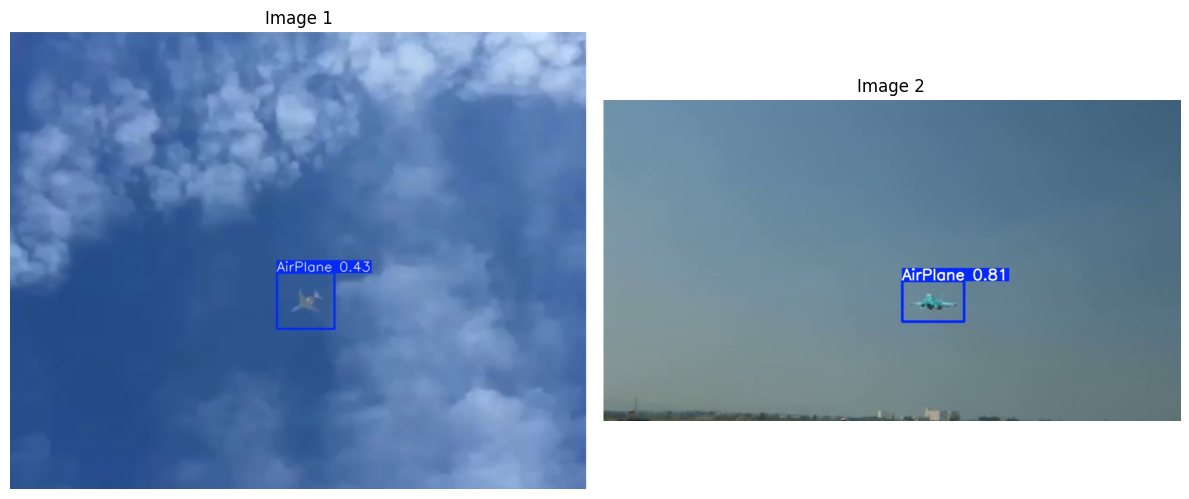

In [48]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load the images
img1 = mpimg.imread('/kaggle/input/pretrained-model-2/Screenshot 2025-09-16 201442.jpg')
img2 = mpimg.imread('/kaggle/input/pretrained-model-2/Screenshot 2025-09-16 201214.jpg')

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Display each image
axs[0].imshow(img1)
axs[0].axis('off')
axs[0].set_title('Image 1')

axs[1].imshow(img2)
axs[1].axis('off')
axs[1].set_title('Image 2')

axs[1].imshow(img2)
axs[1].axis('off')
axs[1].set_title('Image 2')

plt.tight_layout()
plt.show()


## Extracting the output

In [ ]:
import shutil
shutil.make_archive('/kaggle/working/my_output', 'zip', '/kaggle/working/')
from IPython.display import FileLink
FileLink('/kaggle/working/my_output.zip')

# model 2 

In [50]:
# mode2 = YOLO('yolov8n.pt') 

# base_dir = '/kaggle/input/drone-detection-dataset/updated dataset'

# yaml_dir = os.path.join(base_dir, 'data.yaml')

# results=model.train(
#     data=yaml_dir,
#     epochs=15,
#     batch=32,
#     imgsz=640,
#     patience=5,              # Early stopping
#     val=True,
#     name="run_1",
#     project="/kaggle/working/model_2_res",
#     device='cuda',
#     verbose=True,
#     exist_ok=True,
#     save=True
# )

Ultralytics 8.3.201 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/drone-detection-dataset/updated dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=run_1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        765        741      0.931      0.898      0.953       0.62
              AirPlane        133        133       0.92      0.895      0.974      0.695
                 Drone        382        468      0.927      0.842      0.899      0.453
            Helicopter        140        140      0.946      0.957      0.985      0.713
Speed: 0.2ms preprocess, 1.9ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /kaggle/working/model_2_res/run_1


In [51]:
best_model_path = '/kaggle/working/model_2_res/run_1/weights/best.pt' # Path to the best weights from training
best_model_2 = YOLO(best_model_path)

best_model.conf = 0.5     
best_model.iou = 0.45

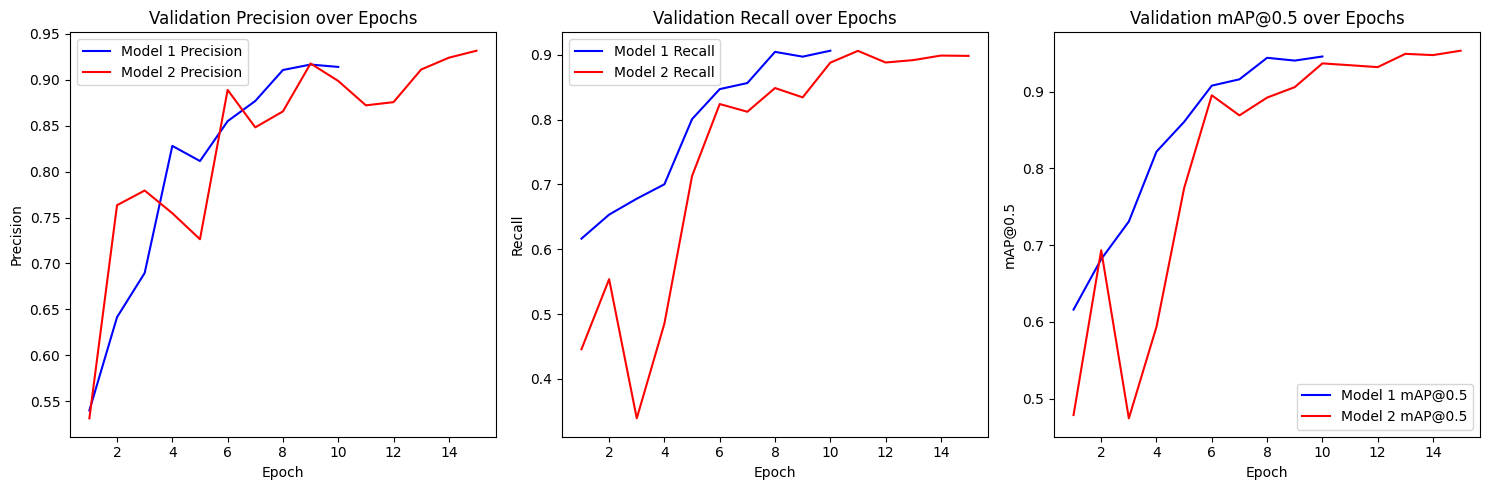

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# Paths for the two models' results
path1 = "/kaggle/input/pretrained-model-2/results.csv"   # Model 1
path2 = "/kaggle/working/model_2_res/run_1/results.csv"   # Model 2

# Load results
df1 = pd.read_csv(path1)
df2 = pd.read_csv(path2)

# -------- Plot Validation Precision, Recall, Accuracy --------
plt.figure(figsize=(15, 5))

# Precision
plt.subplot(1, 3, 1)
plt.plot(df1["epoch"], df1["metrics/precision(B)"], label="Model 1 Precision", color="blue")
plt.plot(df2["epoch"], df2["metrics/precision(B)"], label="Model 2 Precision", color="red")
plt.title("Validation Precision over Epochs")
plt.xlabel("Epoch"); plt.ylabel("Precision"); plt.legend()

# Recall
plt.subplot(1, 3, 2)
plt.plot(df1["epoch"], df1["metrics/recall(B)"], label="Model 1 Recall", color="blue")
plt.plot(df2["epoch"], df2["metrics/recall(B)"], label="Model 2 Recall", color="red")
plt.title("Validation Recall over Epochs")
plt.xlabel("Epoch"); plt.ylabel("Recall"); plt.legend()

# mAP (YOLO doesn’t log accuracy, so we use mAP as a proxy for validation performance)
plt.subplot(1, 3, 3)
plt.plot(df1["epoch"], df1["metrics/mAP50(B)"], label="Model 1 mAP@0.5", color="blue")
plt.plot(df2["epoch"], df2["metrics/mAP50(B)"], label="Model 2 mAP@0.5", color="red")
plt.title("Validation mAP@0.5 over Epochs")
plt.xlabel("Epoch"); plt.ylabel("mAP@0.5"); plt.legend()

plt.tight_layout()
plt.show()


# after 10 epocs Model 1 seems better